#### Descrição do projeto
Uma plataforma online de educação que consegue acompanhar a quantidade de horas que seus alunos passam estudando numa determinada trilha, deseja avaliar  se esta quantidade de horas influencia na pontuação do teste final

A solução vai ser implementada utilizando um algoritmo de regressão linear, de forma que seja possível prever a pontuação do teste final, dada a quantidade de horas de estudo

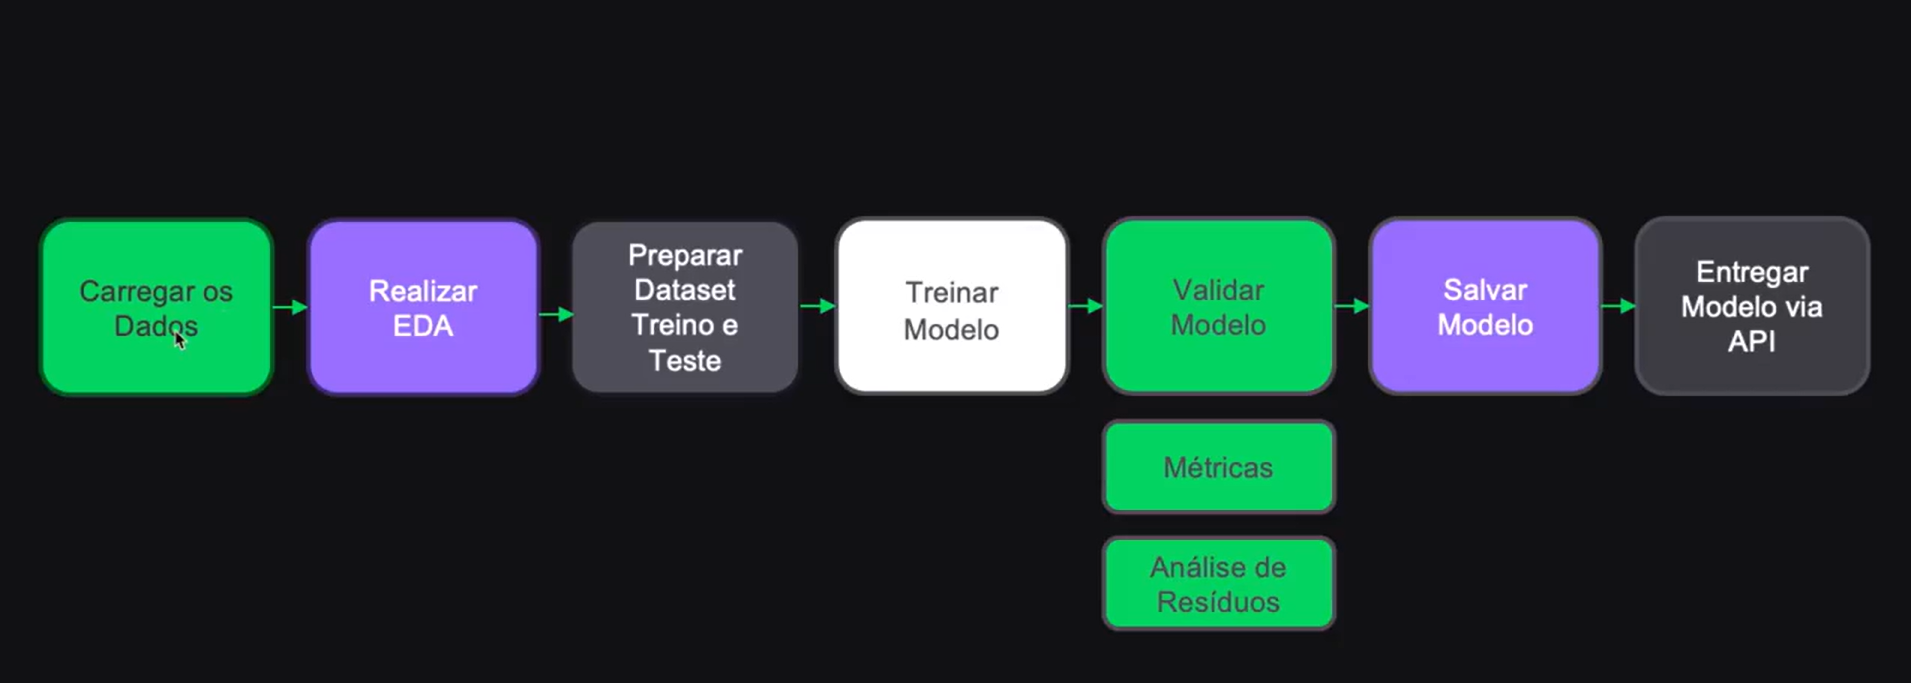

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro,kstest,probplot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.graphics.gofplots import qqplot
import numpy as np 

### Cargas dos dados

In [32]:
# Abrir o dataset

df_pontuacao = pd.read_csv('data.csv')

In [33]:
df_pontuacao

,horas_estudo,pontuacao_teste
0,1.1,30
1,2.0,55
2,2.5,60
3,3.6,75
4,4.2,85
...,...,...
96,46.0,780
97,46.2,785
98,46.4,790
99,46.6,795


In [34]:
df_pontuacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   horas_estudo     101 non-null    float64
 1   pontuacao_teste  101 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


### EDA

In [35]:
# Medidas estatisticas das variaveis

df_pontuacao.describe()

,horas_estudo,pontuacao_teste
count,101.000000,101.000000
mean,28.604950,455.000000
std,14.116128,221.385411
min,1.100000,30.000000
25%,16.500000,270.000000
50%,30.900000,465.000000
75%,41.800000,655.000000
max,46.900000,800.000000


<Axes: xlabel='horas_estudo', ylabel='pontuacao_teste'>

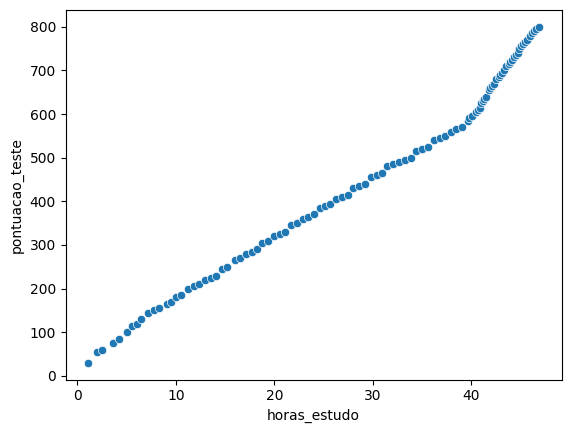

In [36]:
# Plot de Dispersão
# X =  horas de estudo
# y = pontuação

sns.scatterplot(data=df_pontuacao, x = 'horas_estudo', y ='pontuacao_teste' )

<Axes: ylabel='horas_estudo'>

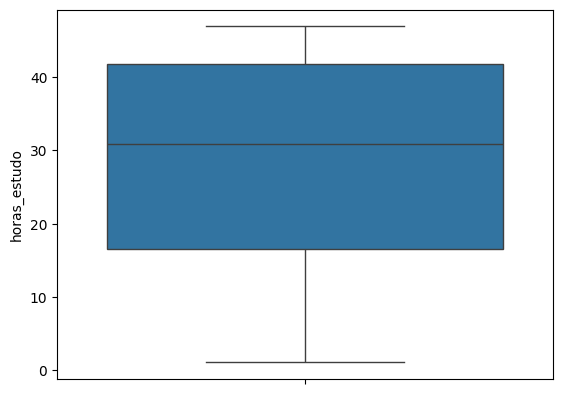

In [37]:
# Verificar se temos outliers

sns.boxplot(df_pontuacao, y ='horas_estudo')

<Axes: >

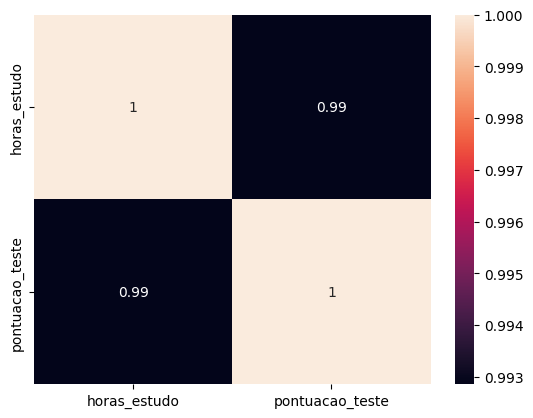

In [38]:
# Verificar Correlação - Pearson

sns.heatmap(df_pontuacao.corr('pearson'), annot = True)


<Axes: >

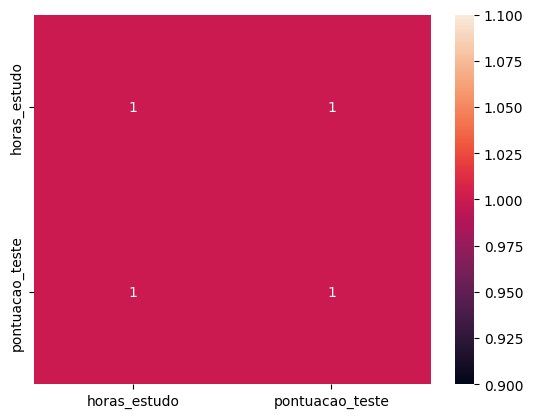

In [39]:
# Verificar Correlação - Spearman

sns.heatmap(df_pontuacao.corr('spearman'), annot = True)

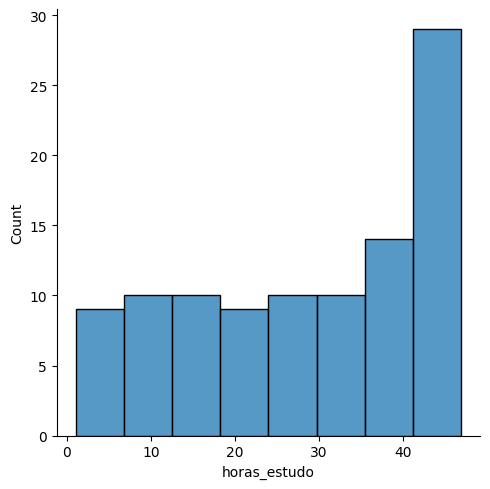

In [40]:
sns.displot(df_pontuacao, x = 'horas_estudo')

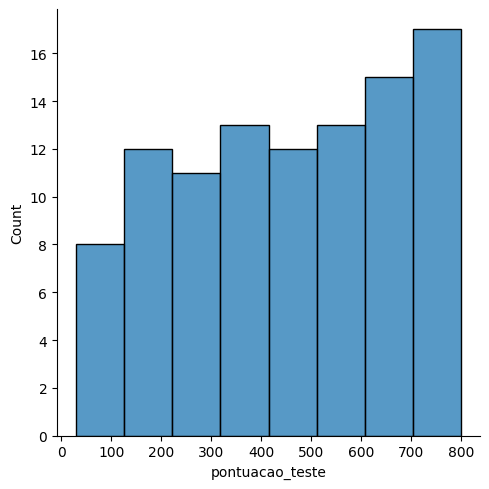

In [41]:
sns.displot(df_pontuacao, x = 'pontuacao_teste')

##### Treinar Modelo

In [42]:
# Dividir dataset entre treino e teste
# Quanto temos apenas uma feature, precisamos ajustar o shape

X = df_pontuacao['horas_estudo'].values.reshape(-1,1)
Y = df_pontuacao['pontuacao_teste'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.30,random_state=50)

In [43]:
# Instaciar o modelo a ser treinado
reg_model = LinearRegression()

In [44]:
# Treinar o modelo

reg_model.fit(X_train, y_train)

LinearRegression()

In [45]:
# Imprimir a equação da reta

# y = ax+b

print(" A equação da reta é y = {:4f}x + {:4f}".format(reg_model.coef_[0][0], reg_model.intercept_[0]))

 A equação da reta é y = 15.642619x + 8.476601


Validar Modelo - Métricas

In [46]:
# Predição dos valores com base no conjunto de testes

y_pred = reg_model.predict(X_test)

In [47]:
# Calcular métrica R-squared ou Coeficiente de Determinação
# R2 representa a proporção na variação na variável dependendente que é explicada pela variável independente

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

r2_score(y_test, y_pred)



0.9828400452912442

In [48]:
# Calcular métrica MAE (Mean Absolute Error)
# MAE = Media (y_test - y_pred)
# É uma métrica fácil de interpretar
# MAE é menos sensivel a outlier

mean_absolute_error(y_test, y_pred)

22.957470277134615

In [49]:
# MSE é mais sensível a outlier e penaliza grandes erros
mean_squared_error(y_test, y_pred)

766.9972992416427

In [50]:
# RMSE (Square root mean error)
#Raiz(Media(y_teste-ypred)2)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 27.69471608884342


In [51]:
import sklearn
print(sklearn.__version__)


1.6.1


<Axes: >

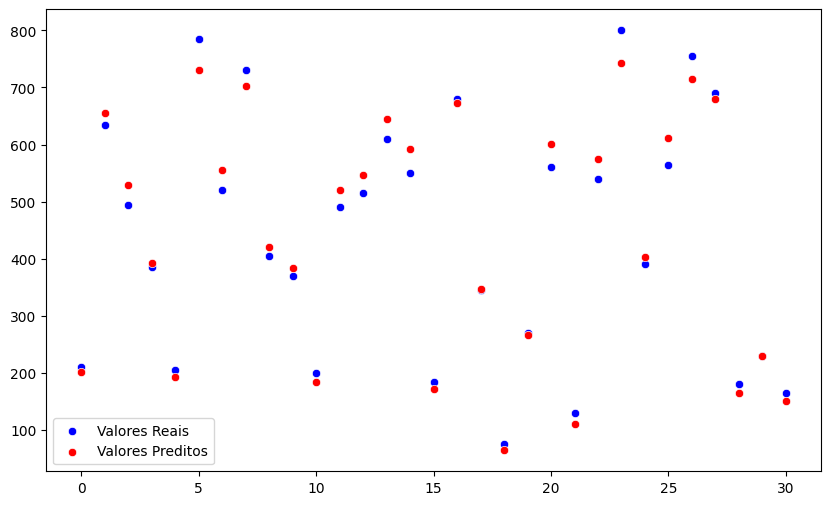

In [52]:
x_axis = range(len(y_test))
plt.figure(figsize=(10,6))
sns.scatterplot(x= x_axis, y = y_test.reshape(-1), color = 'blue', label = 'Valores Reais')
sns.scatterplot(x= x_axis, y = y_pred.reshape(-1), color = 'red' , label = 'Valores Preditos' )

### Análise de Resíduos

In [53]:
# Calcular os residuos
residuos = y_test - y_pred

In [54]:
# Calcular os reísudos padronizados (standardization)
# Para cada elemento de um conjunto (X - media) / desvio_padrao

from scipy.stats import zscore

residuos_std = zscore(residuos)

print (residuos_std)

[[ 0.38486997]
 [-0.59857428]
 [-1.13836535]
 [-0.19055447]
 [ 0.54418647]
 [ 2.06608474]
 [-1.19621501]
 [ 1.09093729]
 [-0.43004125]
 [-0.39451221]
 [ 0.70350297]
 [-0.97904884]
 [-1.03689851]
 [-1.16580625]
 [-1.41338117]
 [ 0.55637083]
 [ 0.35425256]
 [ 0.00429107]
 [ 0.48132084]
 [ 0.23466566]
 [-1.39106055]
 [ 0.83138666]
 [-1.15157377]
 [ 2.21321687]
 [-0.34987098]
 [-1.55037705]
 [ 1.60134366]
 [ 0.49022438]
 [ 0.65886173]
 [ 0.14538318]
 [ 0.6253808 ]]


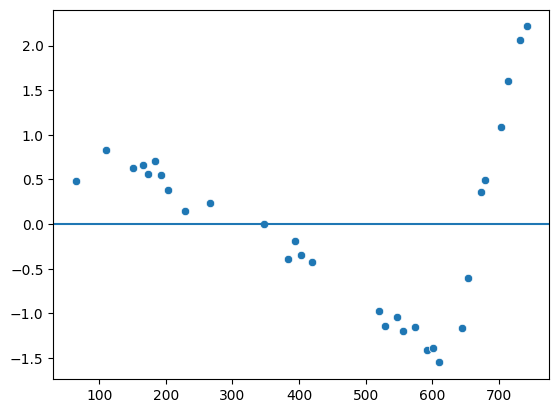

In [55]:
# Verificar Linearidade do modelo : 
# Se os residuos entre -2 e +2 (na escala padrão) - indica linearidade

#Verificar homogeneidade das variâncias  (Homocedasticidade)
# Valores estiver em torno da reta, temos homoceasticidade, caso contrario, 
#Se tivermos alguma tendencia ou padrã (  forma um cone, funil) há hetereocesticidade

sns.scatterplot(x = y_pred.reshape(-1), y= residuos_std.reshape(-1))
plt.axhline(y=0)


Text(0, 0.5, 'Resíduos na escala padrão')

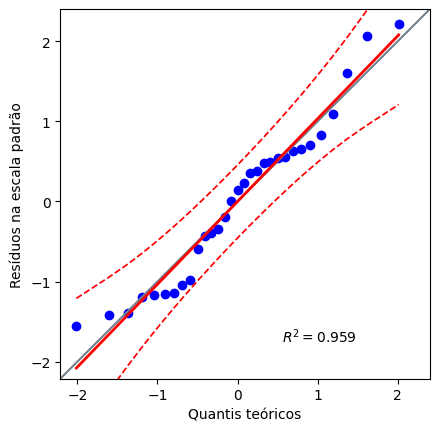

In [56]:
# Checar se residuos seguem uma distribuição normal
# QQ (Quantile-Quantile) plot, que avalia se uma amostra de dados segue uma distribuição normal

import pingouin as pg
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis teóricos')
plt.ylabel('Resíduos na escala padrão')


In [57]:
# teste de normalidade - Shapiro-Wilk
# H0: A amostra é proveniente de uma distribuição normal
# H1: A amostra não é proveniente de uma distribuição normal

stat_shapiro, p_valor_shapiro =shapiro(residuos.reshape(-1))
print("Estatistica de Shapiro:{} e P-valor:{}".format(stat_shapiro, p_valor_shapiro))

Estatistica de Shapiro:0.9500528573989868 e P-valor:0.15663447976112366


In [58]:
# teste de normalidade - Kolmogorov-Smirnov
# H0: A amostra é proveniente de uma distribuição normal
# H1: A amostra não é proveniente de uma distribuição normal

stat_ks, p_valor_ks =kstest(residuos.reshape(-1), 'norm')
print("Estatistica de Ks:{} e P-valor:{}".format(stat_ks, p_valor_ks))

Estatistica de Ks:0.48355808450512827 e P-valor:3.395368995814077e-07


### Fazer predições com o modelo

In [59]:
# Se eu estudar 30.4 horas qual a pontuação prevista pelo modelo?

reg_model.predict([[30.4]])

array([[484.01220436]])

In [60]:
# Quantas horas estudar para obter 600 pontos?
# y= ax+b
# y - b = ax
# (y-b)/a = x

(600 - reg_model.intercept_[0])/reg_model.coef_[0][0]

37.81485802710669

#### Salvar o modelo para usar depois

In [61]:
import joblib

joblib.dump(reg_model, 'modelo_regressao_linear.pkl')

['modelo_regressao_linear.pkl']